In [4]:
# !pip install --upgrade --no-cache-dir \
#     boto3 \
#     botocore \
#     faiss-cpu \
#     ipython \
#     langchain \
#     langchain-community \
#     langgraph \
#     pandas \
#     pydantic \
#     pyowm \
#     tavily-python \
#     langchain-aws \
#     python-dotenv

In [5]:
# Standard library imports
import json
import logging
import os
import sys
import traceback
from datetime import datetime
from typing import List, Dict
from dotenv import load_dotenv, find_dotenv

# AWS and third-party imports
import boto3
import pandas as pd
import sqlite3
from IPython.display import Image, display
from pydantic import BaseModel, Field
from tavily import TavilyClient

# LangChain imports
from langchain_core.documents import Document
from langchain_community.vectorstores import FAISS
from langchain_aws import BedrockEmbeddings
from langchain_community.utilities import OpenWeatherMapAPIWrapper
from langchain_core.runnables.graph import MermaidDrawMethod
from langchain_text_splitters import RecursiveJsonSplitter

# LangGraph imports
from langgraph.graph import StateGraph, END
from langchain_core.messages import ToolMessage
from langgraph.checkpoint.memory import MemorySaver

In [7]:
# !pip freeze > requirements.txt

In [8]:
# Set up logging
logging.basicConfig(level=logging.INFO, stream=sys.stdout, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

In [9]:
# Set up API Keys
_ = load_dotenv(find_dotenv())
AWS_REGION = "us-east-1"
DEFAULT_MODEL = "mistral.mistral-large-2402-v1:0"
DEFAULT_EMBEDDINGS = "amazon.titan-embed-text-v2:0"

In [10]:
# Initialize Bedrock client
session = boto3.Session(profile_name='amplify-dev', region_name=AWS_REGION)
bedrock_client = session.client(service_name='bedrock-runtime')

2026-04-06 16:08:48,457 - INFO - Found credentials in shared credentials file: ~/.aws/credentials


In [11]:
# Define state structure using Pydantic
class State(BaseModel):
    city: str
    messages: List[Dict] = Field(default_factory=list)
    events_result: str = ""
    search_result: str = ""
    weather_info: Dict[str, str] = Field(default_factory=dict)
    analysis_result: str = ""
    restaurant_recommendations: str = ""

print("Setup complete!")

Setup complete!


In [12]:
# Load the JSON file directly into a DataFrame
df = pd.read_json('./data/eventsDB_data.json')

# Initialize the SQLite database with the DataFrame
def initialize_database(db_path, df):
    conn = sqlite3.connect(db_path)
    df.to_sql('local_events', conn, if_exists='replace', index=False)
    conn.close()
    print(f"Database initialized with {len(df)} events.")

# Initialize the database
db_path = 'local_info.db'
initialize_database(db_path, df)

Database initialized with 54 events.


In [13]:
def generate_text(bedrock_client, model_id, tool_config, input_text):
    print("\nGenerating text with model:", model_id)

    is_mistral_model = model_id.startswith("mistral.")

    # Create the initial message from the user input.
    messages = [{"role": "user",
                 "content": [{"text": input_text}]
    }]

    inference_config = {
        "temperature": 0.5,
        "topP": 0.9,
        "maxTokens": 8192
    } if is_mistral_model else {}

    kwargs = {
        "modelId": model_id,
        "messages": messages,
        "inferenceConfig": inference_config
    }

    if tool_config:
        kwargs["toolConfig"] = tool_config

    tool_result = None  # Initialize tool_result

    while True:
        response = bedrock_client.converse(**kwargs)
        output_message = response['output']['message']
        messages.append(output_message)  # Add assistant's response to messages
        
        stop_reason = response.get('stopReason')

        if stop_reason == 'tool_use' and tool_config:
            tool_use = output_message['content'][0]['toolUse']
            tool_use_id = tool_use['toolUseId']
            tool_name = tool_use['name']
            tool_input = tool_use['input']
  
            try:
                if tool_name == 'get_upcoming_events':
                    tool_result = events_database_tool(tool_input['city'])
                    json_result = json.dumps({"events": tool_result})
                elif tool_name == 'get_city_weather':
                    tool_result = weather_tool(tool_input['city'])
                    json_result = json.dumps({"weather": tool_result})
                elif tool_name == 'search_and_summarize_events':
                    tool_result = search_tool(tool_input['city'])
                    json_result = json.dumps({"events": tool_result})
                else:
                    raise ValueError(f"Unknown tool: {tool_name}")
                
                tool_response = {
                    "toolUseId": tool_use_id,
                    "content": [{"json": json.loads(json_result)}]
                }

            except Exception as e:
                print(f"Error using tool {tool_name}: {str(e)}")
                tool_response = {
                    "toolUseId": tool_use_id,
                    "content": [{"text": f"Error using {tool_name}: {str(e)}"}],
                    "status": "error"
                }
                tool_result = None  # Set tool_result to None in case of an error

            messages.append({
                "role": "user",
                "content": [{"toolResult": tool_response}]
            })

            # Update kwargs with new messages
            kwargs["messages"] = messages
        else:
            break

    return output_message, tool_result

In [14]:
print(os.getenv('AWS_PROFILE'))

amplify-dev


In [15]:
def create_restaurant_vector_store(df):
    # Convert DataFrame to list of dictionaries
    print("Converting DataFrame to list of dictionaries...")
    data = df.to_dict('records')

    # Use RecursiveJsonSplitter to split documents
    print("Splitting documents...")
    json_splitter = RecursiveJsonSplitter(max_chunk_size=1000)

    split_texts = []
    metadata_list = []  # List to store metadata for each document
    for item in data:
        # Split the document into chunks
        split_texts.extend(json_splitter.split_text(json_data=item, convert_lists=True))
        
        # Directly extract metadata from the dictionary. To be used by similarity_search with filter_criteria
        metadata = {
            "city": item.get('city', ''),
            "stars": item.get('stars', 0),
            "name": item.get('name', ''),
        }
        metadata_list.append(metadata)
    
    # Create documents from split texts and attach corresponding metadata
    split_documents = [Document(page_content=text, metadata=metadata) for text, metadata in zip(split_texts, metadata_list)]

    # Initialize Bedrock Embeddings
    print("Initializing embeddings...")
    bedrock_embeddings = BedrockEmbeddings(
        region_name=AWS_REGION,
        model_id=DEFAULT_EMBEDDINGS
    )

    # Create vector store
    print("Creating vector store...")
    vectorstore = FAISS.from_documents(split_documents, bedrock_embeddings)
    num_documents = len(vectorstore.index_to_docstore_id)
    
    return vectorstore, num_documents

# Example DataFrame load
df = pd.read_json('./data/restaurant_data.json')
# Remove duplicates based on the 'name' column, keeping the first occurrence
df_cleaned = df.drop_duplicates(subset=['name'], keep='first')

restaurant_vectorstore, num_documents = create_restaurant_vector_store(df_cleaned)
print(f"Restaurant Vector Store created successfully. \nNumber of documents indexed: {num_documents}")

Converting DataFrame to list of dictionaries...
Splitting documents...
Initializing embeddings...
2026-04-06 16:09:24,146 - INFO - Found credentials in shared credentials file: ~/.aws/credentials
Creating vector store...
2026-04-06 16:09:24,846 - INFO - Successfully invoked model amazon.titan-embed-text-v2:0. ResponseMetadata: {'RequestId': '8ccb96c2-08ac-456a-a4e3-c78cb334b3cc', 'HTTPStatusCode': 200, 'HTTPHeaders': {'date': 'Mon, 06 Apr 2026 21:09:24 GMT', 'content-type': 'application/json', 'content-length': '43292', 'connection': 'keep-alive', 'x-amzn-requestid': '8ccb96c2-08ac-456a-a4e3-c78cb334b3cc', 'x-amzn-bedrock-invocation-latency': '145', 'x-amzn-bedrock-input-token-count': '100'}, 'RetryAttempts': 0}
2026-04-06 16:09:25,036 - INFO - Successfully invoked model amazon.titan-embed-text-v2:0. ResponseMetadata: {'RequestId': 'ce5f9293-4ab1-404f-b5b6-b73cf61eef93', 'HTTPStatusCode': 200, 'HTTPHeaders': {'date': 'Mon, 06 Apr 2026 21:09:25 GMT', 'content-type': 'application/json', 

In [16]:
def query_restaurants_RAG(city, vectorstore):
    query = f"Find restaurants with 4 stars or higher ratings in {city} and describe their key features"
    print(f"\nPerforming query: {query}")

    # Define the filter based on city and star rating
    filter_criteria = {
        "stars": {"$gte": 4},  # Filter for ratings >= 4 stars
        "city": city   # Filter for the specific city (case-insensitive)
    }

    # Perform similarity search with filter
    relevant_docs = vectorstore.similarity_search(query, k=5, filter=filter_criteria)

    # Display the relevant documents
    if relevant_docs:
        print(f"\nTop {len(relevant_docs)} relevant documents for high-rated restaurants in {city}:")
        for i, doc in enumerate(relevant_docs, 1):
            print(f"\nDocument {i}:")
            print(doc.page_content)
        context = "\n\n".join([doc.page_content for doc in relevant_docs])
    else:
        print(f"No high-rated restaurants found in the vector DB for {city}.")
        context = ""

    # Generate the prompt for Bedrock
    prompt = f"""Task: Provide information about highly-rated restaurants (4 stars and above) in {city}.

    Instructions:
    1. If the following context contains information about restaurants in {city}, describe the key features that contribute to their high ratings. Consider aspects such as cuisine type, ambiance, service, price range, and any standout characteristics.
    2. Only use the information provided in the context. If certain information is not available, state that it's not mentioned.
    3. If no information is provided in the context, respond with: "I'm sorry, but I couldn't find any information about highly-rated restaurants in {city}."
    4. Do not generate or invent any information about restaurants if none is provided in the context.

    Context:
    {context}

    Please provide your response based on these instructions:"""

    # Generate text using the Bedrock model (or your chosen LLM)
    output_message, _ = generate_text(bedrock_client, DEFAULT_MODEL, None, prompt)

    # Extract the response content from the model's output
    response_content = output_message.get('content', [{}])[0].get('text', f"I'm sorry, but I couldn't find any information about highly-rated restaurants in {city}.")
    
    print("\nGenerated response:")
    print(response_content)

    return response_content

In [17]:
city="Tampa"
df_cleaned_count = df_cleaned[df_cleaned['city'] == city].shape[0]
print(f"Number of records with {city} as the city in df_cleaned: {df_cleaned_count}")
query_restaurants_RAG(city, restaurant_vectorstore)

Number of records with Tampa as the city in df_cleaned: 10

Performing query: Find restaurants with 4 stars or higher ratings in Tampa and describe their key features
2026-04-06 16:09:49,501 - INFO - Successfully invoked model amazon.titan-embed-text-v2:0. ResponseMetadata: {'RequestId': '606cd2b1-0aae-4c64-a890-984ba06f1878', 'HTTPStatusCode': 200, 'HTTPHeaders': {'date': 'Mon, 06 Apr 2026 21:09:49 GMT', 'content-type': 'application/json', 'content-length': '43329', 'connection': 'keep-alive', 'x-amzn-requestid': '606cd2b1-0aae-4c64-a890-984ba06f1878', 'x-amzn-bedrock-invocation-latency': '92', 'x-amzn-bedrock-input-token-count': '17'}, 'RetryAttempts': 0}

Top 5 relevant documents for high-rated restaurants in Tampa:

Document 1:
{"name": "Tampa Bay Seafood House", "address": "123 Harbor Drive", "city": "Tampa", "state": "FL", "postal_code": 33602, "stars": 4.5, "review_count": 350, "is_open": 1, "attributes": {"has_tv": true, "outdoor_seating": true, "wifi": false}, "categories": "S

"Based on the provided context, here are the key features of the highly-rated restaurants in Tampa:\n\n1. Tampa Bay Seafood House:\n   - Cuisine Type: Seafood, Restaurant, Bar\n   - Standout Characteristics: Outdoor seating and TV available\n   - Price Range: Not mentioned\n   - Ambiance: Not explicitly mentioned, but the presence of a TV and outdoor seating suggests a casual, relaxed atmosphere\n   - Service: Not mentioned\n\n2. Datz:\n   - Cuisine Type: American (New), Breakfast & Brunch, Gastropubs\n   - Standout Characteristics: Accepts credit cards, good for kids, and has a full bar\n   - Price Range: Not mentioned\n   - Ambiance: Not explicitly mentioned, but the fact it's good for kids and has a full bar suggests a family-friendly yet lively atmosphere\n   - Service: Not mentioned\n\n3. The Columbia Restaurant:\n   - Cuisine Type: Spanish, Cuban, Restaurant\n   - Standout Characteristics: Accepts reservations, offers outdoor seating, and valet parking\n   - Price Range: Not ment

In [18]:
def events_database_tool(city: str) -> str:
    conn = sqlite3.connect(db_path)
    query = """
        SELECT event_name, event_date, description 
        FROM local_events 
        WHERE city = ?
        ORDER BY event_date
        LIMIT 3
    """
    df = pd.read_sql_query(query, conn, params=(city,))
    conn.close()
    print(df)
    if not df.empty:
        events = df.apply(lambda row: f"{row['event_name']} on {row['event_date']}: {row['description']}", axis=1).tolist()
        return "\n".join(events)
    else:
        return f"No upcoming events found for {city}."

In [20]:
def weather_tool(city: str) -> str:
    weather = OpenWeatherMapAPIWrapper()
    tool_result = weather.run("Tampa")
    return tool_result

In [21]:
def search_tool(city: str) -> str:
    client = TavilyClient(api_key=os.environ['TAVILY_API_KEY'])
    query = f"What are the upcoming events in {city}?"
    response = client.search(query, search_depth="advanced")
    results_content = "\n\n".join([result['content'] for result in response['results']])
    return results_content

In [22]:
def events_database_agent(state: State) -> State:
    print("\n" + "*" * 50)
    print("events_database_agent function called")
    print("*" * 50)
    tool_config = {
        "tools": [
            {
                "toolSpec": {
                    "name": "get_upcoming_events",
                    "description": "Get upcoming events for a specific city from the local database",
                    "inputSchema": {
                        "json": {
                            "type": "object",
                            "properties": {
                                "city": {
                                    "type": "string",
                                    "description": "The name of the city to look up events for"
                                }
                            },
                            "required": ["city"]
                        }
                    }
                }
            }
        ]
    }
    
    input_text = f"Get upcoming events for {state.city} from the local database"
    output_message, tool_result = generate_text(bedrock_client, DEFAULT_MODEL, tool_config, input_text)
    
    if tool_result:
        state.events_result = tool_result
    else:
        state.events_result = "No event information available in the local database."
    
    print(f"Events set to: {state.events_result}")
    return state

In [23]:
def search_agent(state: State) -> State:
    print("\n" + "*" * 50)
    print("search_agent function called")
    print("*" * 50)
    tool_config = {
        "tools": [
            {
                "toolSpec": {
                    "name": "search_and_summarize_events",
                    "description": "Search for and summarize upcoming events for a specific city",
                    "inputSchema": {
                        "json": {
                            "type": "object",
                            "properties": {
                                "city": {
                                    "type": "string",
                                    "description": "The name of the city to look up events for"
                                }
                            },
                            "required": ["city"]
                        }
                    }
                }
            }
        ]
    }
    
    input_text = f"Search for and summarize upcoming events in {state.city}"
    output_message, tool_result = generate_text(bedrock_client, DEFAULT_MODEL, tool_config, input_text)
    
    if tool_result:
        state.search_result = tool_result
    else:
        state.search_result = "No event information available from online search."
    
    print(f"Search result set to: {state.search_result[:500]}...")  # Print first 500 characters
    return state

In [24]:
def weather_agent(state: State) -> State:
    print("\n" + "*" * 50)
    print("weather_agent function called")
    print("*" * 50)
    tool_config = {
        "tools": [
            {
                "toolSpec": {
                    "name": "get_city_weather",
                    "description": "Get current weather information for a specific city",
                    "inputSchema": {
                        "json": {
                            "type": "object",
                            "properties": {
                                "city": {
                                    "type": "string",
                                    "description": "The name of the city to look up weather for"
                                }
                            },
                            "required": ["city"]
                        }
                    }
                }
            }
        ]
    }
    
    input_text = f"Get current weather for {state.city}"
    output_message, tool_result = generate_text(bedrock_client, DEFAULT_MODEL, tool_config, input_text)
    
    if tool_result:
        state.weather_info = {"city": state.city, "weather": tool_result}
    else:
        state.weather_info = {"city": state.city, "weather": "Weather information not available."}
    
    print(f"Weather info set to: {state.weather_info}")
    return state

In [25]:
def query_restaurants_agent(state: State) -> State:
    print("\n" + "*" * 50)
    print("query_restaurants_agent function called")
    print("*" * 50)
    state.restaurant_recommendations = query_restaurants_RAG(state.city, restaurant_vectorstore)
    print(f"Restaurant recommendations set for {state.city}")
    return state

In [26]:
def analysis_agent(state: State) -> State:
    print("\n" + "*" * 50)
    print("analysis_agent function called")
    print("*" * 50)
    input_text = f"""Analyze the following information about {state.city}:

Events from local database: {state.events_result}
Events from online search: {state.search_result}
Weather: {state.weather_info['weather']}
Restaurant Recommendations: {state.restaurant_recommendations}

Please provide:
1. A brief weather analysis
2. Suggested activities based on the weather and events (from both local and online sources)
3. Outfit recommendations considering the weather
4. A summary of recommended restaurants and dining options"""

    output_message, _ = generate_text(bedrock_client, DEFAULT_MODEL, None, input_text)

    if 'content' in output_message and len(output_message['content']) > 0:
        state.analysis_result = output_message['content'][0]['text']
    else:
        state.analysis_result = "Unable to generate analysis."

    state.messages.append({"role": "assistant", "content": [{"text": state.analysis_result}]})
    
    print(f"Analysis result: {state.analysis_result[:500]}...")  # Print first 500 characters
    return state

In [27]:
# Define the graph
def build_graph():
    workflow = StateGraph(State)

    workflow.add_node("Events Database Agent", events_database_agent)
    workflow.add_node("Online Search Agent", search_agent)
    workflow.add_node("Weather Agent", weather_agent)
    workflow.add_node("Restaurants Recommendation Agent", query_restaurants_agent)
    workflow.add_node("Analysis Agent", analysis_agent)

    workflow.set_entry_point("Events Database Agent")

    # Add conditional edge
    def route_events(state):
        print(f"Routing events. Current state: {state}")
        print(f"Events content: '{state.events_result}'")
        if f"No upcoming events found for {state.city}" in state.events_result:
            print("No events found in local DB. Routing to Online Search Agent.")
            return "Online Search Agent"
        else:
            print("Events found in local DB. Routing to Weather Agent.")
            return "Weather Agent"

    workflow.add_conditional_edges(
        "Events Database Agent",
        route_events,
        {
            "Online Search Agent": "Online Search Agent",
            "Weather Agent": "Weather Agent"
        }
    )

    workflow.add_edge("Online Search Agent", "Weather Agent")
    workflow.add_edge("Weather Agent", "Restaurants Recommendation Agent")
    workflow.add_edge("Restaurants Recommendation Agent", "Analysis Agent")
    workflow.add_edge("Analysis Agent", END)
    
    # Initialize memory to persist state between graph runs
    checkpointer = MemorySaver()

    # Compile the workflow
    app = workflow.compile(checkpointer=checkpointer)
    print("Workflow compiled successfully")
        
    # Visualize the graph
    display(
        Image(
            app.get_graph().draw_mermaid_png(
                draw_method=MermaidDrawMethod.API
            )
        )
    )

    #return app and checkpointer
    return app, checkpointer

print("Graph construction function defined.")

Graph construction function defined.


In [28]:
# Main execution
def main(city: str):
    try:
        print(f"Starting main execution for city: {city}")
        app, checkpointer = build_graph()
        print("Graph built successfully")
                
        initial_state = State(
            city=city,
            messages=[{"role": "user", "content": [{"text": f"What's happening in {city} and what should I wear?"}]}],
            events_result="",
            weather_info={},
            analysis_result="",
            search_result="",
            restaurant_recommendations=""
        )

        # Configuration for the stream and checkpointer
        config = {
            "recursion_limit": 150,
            "configurable": {
                "thread_id": "42"  # Using string as thread_id
            }
        }

        print("Starting to stream events")
        # Stream the events with the required configurable key
        events = app.stream(
            initial_state,
            config=config
        )

        for output in events:
            if "__end__" not in output:
                print(f"\nIntermediate output: {output}")

        # Access the final state from the checkpointer
        final_state_dict = checkpointer.get(config=config)

        # Print the final response from the assistant
        if 'channel_values' in final_state_dict and 'messages' in final_state_dict['channel_values']:
            messages = final_state_dict['channel_values']['messages']
            if messages and isinstance(messages, list):
                final_message = messages[-1]
                if final_message.get("role") == "assistant":
                    print("\nFinal response from the assistant:")
                    print(json.dumps(final_message["content"], indent=2))
                else:
                    print("\nNo final response from the assistant found in the messages.")
            else:
                print("\nNo valid messages found in the final state.")
        else:
            print("\nNo messages found in the final state.")

        # Print the full final state from checkpointer
        print("\nFinal state from checkpointer:")
        print(json.dumps(final_state_dict, indent=2))
        
    except Exception as e:
        print(f"An error occurred in main execution: {str(e)}")
        print(traceback.format_exc())

print("Main execution function defined.")

Main execution function defined.


Starting script execution for city: Tampa
Starting main execution for city: Tampa
Workflow compiled successfully


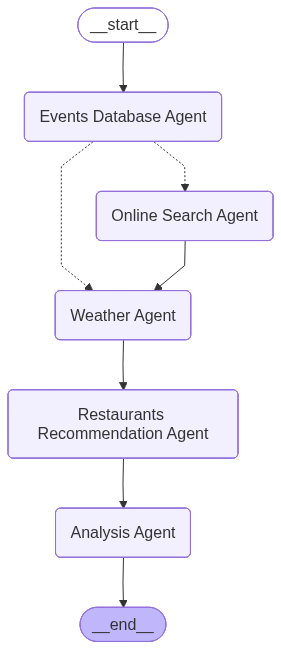

Graph built successfully
Starting to stream events

**************************************************
events_database_agent function called
**************************************************

Generating text with model: mistral.mistral-large-2402-v1:0
Empty DataFrame
Columns: [event_name, event_date, description]
Index: []
Events set to: No upcoming events found for Tampa.
Routing events. Current state: city='Tampa' messages=[{'role': 'user', 'content': [{'text': "What's happening in Tampa and what should I wear?"}]}] events_result='No upcoming events found for Tampa.' search_result='' weather_info={} analysis_result='' restaurant_recommendations=''
Events content: 'No upcoming events found for Tampa.'
No events found in local DB. Routing to Online Search Agent.

Intermediate output: {'Events Database Agent': {'city': 'Tampa', 'messages': [{'role': 'user', 'content': [{'text': "What's happening in Tampa and what should I wear?"}]}], 'events_result': 'No upcoming events found for Tampa

In [29]:
if __name__ == "__main__":
    city = "Tampa"
    print(f"Starting script execution for city: {city}")
    main(city)